¿Cuantas llamadas entrantes y salientes se registran por mes en el call center sujeto del analisis?

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import data_table
data_table.enable_dataframe_formatter()

df_motivos=pd.read_csv('motivos_llamada.csv')
df_llamadas=pd.read_csv('llamadas.csv')
df_completo = pd.merge(df_llamadas, df_motivos, on='id_motivo', how='left')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
df_completo['fecha_hora_inicio'] = pd.to_datetime(df_completo['fecha_hora_inicio'])
df_completo['fecha_hora_inicio'] = pd.to_datetime(df_completo['fecha_hora_inicio'])
df_completo['mes']=df_completo['fecha_hora_inicio'].dt.to_period('M').astype(str)
resultado_mensual= df_completo.groupby(['mes','tipo_llamada']).size().reset_index(name='cantidad')
display(resultado_mensual)

,mes,tipo_llamada,cantidad
0,2025-10,entrante,9985
1,2025-10,saliente,2318
2,2025-11,entrante,16735
3,2025-11,saliente,3405
4,2025-12,entrante,18285
5,2025-12,saliente,3928
6,2026-01,entrante,17831
7,2026-01,saliente,3677
8,2026-02,entrante,15969
9,2026-02,saliente,3377


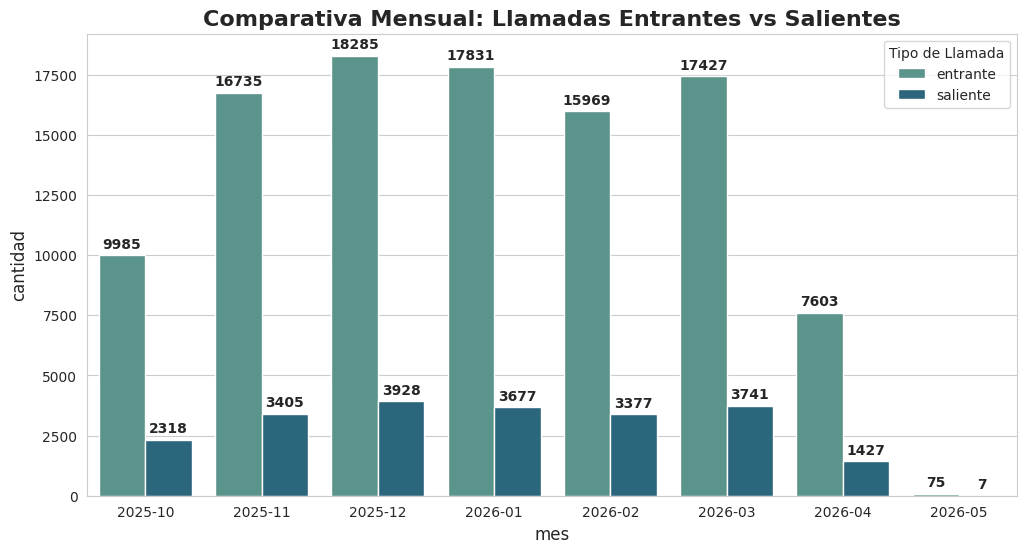

In [7]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
grafico_comparativo= sns.barplot (
    data=resultado_mensual,
    x='mes',
    y='cantidad',
    hue='tipo_llamada',
    palette='crest'
)
plt.title('Comparativa Mensual: Llamadas Entrantes vs Salientes', fontsize=16,fontweight='bold')
plt.xlabel('mes',fontsize=12)
plt.ylabel('cantidad',fontsize=12)
plt.legend(title='Tipo de Llamada')
for i in grafico_comparativo.containers:
  grafico_comparativo.bar_label(i,padding=3, fontweight='bold')